# FinSight RAG Architecture Experiments — Evaluation

Comparative evaluation of retrieval-augmented generation architectures on the FinSight SEC-filing QA pipeline.

| | |
|---|---|
| **Experiments** | E-1 baseline characterization · E-2 architecture comparison · E-3 prompt/context engineering |
| **Corpus** | 6 10-K filings: AAPL FY2024+25, MSFT FY2024+25, NVDA FY2025+26 (~1,300 chunks, RavenDB vector store) |
| **Eval set** | `questions.v1.jsonl` test split — 16 questions (4 single-hop / 4 multi-hop / 4 aggregation / 4 temporal), 44% post-cutoff; every numeric gold value verified against SEC XBRL **and** literal presence in the indexed filing text |
| **Generation** | `gemini-3.1-flash-lite`, temp 0.2, k=5, n=3 repeats per question |
| **Judge** | `gemma-4-31b-it`, temp 0, judge prompts v3, blinded (never sees variant identity) |
| **Pre-registration** | All hypotheses + refutation criteria written before running: `.claude/EXPERIMENTS.md` |
| **Run dates** | 2026-07-10 … 2026-07-11 |

**Architectures (E-2)** — one module each in `backend/data_extract/rag_variants/`:
`naive` (production vector RAG, the baseline) · `graph` (XBRL RDF + SPARQL router over `backend/graph/`) · `hyde` (hypothetical-document retrieval) · `agentic` (plan→retrieve→reflect loop, bounded) · `modular` (rewrite/expand → multi-search → RRF → LLM rerank).

**Prompt/context arms (E-3)** — retrieval byte-identical to `naive`; only the prompt/context changes:
`prompt_minimal` · `prompt_fewshot` · `ctx_metadata` (relevance-order + metadata manifest) · `prompt_quote_first` (two-stage evidence scaffold — our suggested technique).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(".")  # run from experiments/rag/results/

SLICES = ["single-hop", "multi-hop", "aggregation", "temporal"]

# Fixed variant -> color (validated categorical palette; color follows entity
# across every figure; never cycled).
C = {
    "naive":              "#2a78d6",  # blue
    "graph":              "#eb6834",  # orange
    "hyde":               "#1baf7a",  # aqua
    "agentic":            "#eda100",  # yellow
    "modular":            "#e87ba4",  # magenta
    "prompt_minimal":     "#008300",  # green
    "prompt_fewshot":     "#4a3aa7",  # violet
    "ctx_metadata":       "#e34948",  # red
    "prompt_quote_first": "#e87ba4",  # magenta (never co-plotted with modular)
}

E2_VARIANTS = ["naive", "graph", "hyde", "agentic", "modular"]
E3_VARIANTS = ["naive", "prompt_minimal", "prompt_fewshot", "ctx_metadata", "prompt_quote_first"]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})


def load_scores(exp: str) -> pd.DataFrame:
    frames = []
    for p in sorted((ROOT / exp / "scores").glob("*.jsonl")):
        if p.stem in ("judge_cache",):
            continue
        frames.append(pd.read_json(p, lines=True))
    return pd.concat(frames, ignore_index=True)


def block_from_scores(df: pd.DataFrame) -> dict:
    """Aggregate one group of scored runs exactly like scorer.aggregate()."""
    qmeans = df.groupby("qid").correctness.mean()
    out = {
        "n_questions": df.qid.nunique(), "n_runs": len(df),
        "n_errors": int(df.error.notna().sum()),
        "correctness_mean": qmeans.mean(),
        "correctness_std_across_questions": qmeans.std(ddof=1) if len(qmeans) > 1 else 0.0,
    }
    for col in ["recall_at_k", "precision_at_k", "mrr", "faithfulness",
                "citation_validity", "citation_support",
                "total_tokens", "prompt_tokens", "completion_tokens",
                "retrieval_calls", "llm_calls"]:
        out[col] = df[col].dropna().mean() if col in df else np.nan
    out["latency_p50_ms"] = df.latency_ms.median()
    out["latency_p95_ms"] = df.latency_ms.quantile(0.95)
    out["facts_found_ratio"] = df.facts_found.sum() / max(1, df.facts_expected.sum())
    return out


def tidy(exp: str) -> pd.DataFrame:
    """Per-variant per-slice aggregates. Prefers summary.json; falls back to
    computing from scores/*.jsonl (E-2 while its summary was pending)."""
    sp = ROOT / exp / "summary.json"
    rows = []
    if sp.exists():
        s = json.loads(sp.read_text(encoding="utf-8"))
        for v, blocks in s["variants"].items():
            for sl, b in blocks.items():
                b = dict(b)
                b["faithfulness"] = b.pop("faithfulness_mean_0to2", None)
                b["total_tokens"] = b.pop("tokens_per_q_mean", None)
                b["prompt_tokens"] = b.pop("prompt_tokens_mean", None)
                b["completion_tokens"] = b.pop("completion_tokens_mean", None)
                b["retrieval_calls"] = b.pop("retrieval_calls_mean", None)
                b["llm_calls"] = b.pop("llm_calls_mean", None)
                rows.append({"exp": exp, "variant": v, "slice": sl, **b})
    else:
        df = load_scores(exp)
        for v, g in df.groupby("variant"):
            rows.append({"exp": exp, "variant": v, "slice": "overall", **block_from_scores(g)})
            for sl, gg in g.groupby("slice"):
                rows.append({"exp": exp, "variant": v, "slice": sl, **block_from_scores(gg)})
            pc = g[g.post_cutoff]
            if len(pc):
                rows.append({"exp": exp, "variant": v, "slice": "post_cutoff_subset",
                             **block_from_scores(pc)})
    return pd.DataFrame(rows)


# Completeness gate — read this before trusting any chart below.
print(f"{'exp':5s} {'variant':20s} {'scored':>6s} {'errors':>6s}  source")
for exp in ["E-1", "E-2", "E-3"]:
    df = load_scores(exp)
    src = "summary.json" if (ROOT / exp / "summary.json").exists() else "scores/*.jsonl (fallback)"
    for v, g in df.groupby("variant"):
        flag = "" if len(g) == 48 and g.error.notna().sum() == 0 else "  <-- CHECK"
        print(f"{exp:5s} {v:20s} {len(g):>6d} {int(g.error.notna().sum()):>6d}  {src}{flag}")

S1, S2, S3 = tidy("E-1"), tidy("E-2"), tidy("E-3")
R2, R3 = load_scores("E-2"), load_scores("E-3")

exp   variant              scored errors  source
E-1   naive                    48      0  summary.json
E-2   agentic                  48      0  summary.json
E-2   graph                    48      0  summary.json
E-2   hyde                     48      0  summary.json
E-2   modular                  48      0  summary.json
E-2   naive                    48      0  summary.json
E-3   ctx_metadata             48      0  summary.json
E-3   naive                    48      0  summary.json
E-3   prompt_fewshot           48      0  summary.json
E-3   prompt_minimal           48      0  summary.json
E-3   prompt_quote_first       48      0  summary.json


## Methodology in brief (details: `../METRICS.md`, reports: `../../../.claude/evidence/experiments/`)

- **Primary metric (registered):** answer correctness on the **multi-hop + aggregation** slices of the held-out test split. Everything else is diagnostic or guardrail.
- **Correctness** per question = mean over gold facts. Numeric facts scored by a **deterministic matcher** (unit/scale normalization, ±0.5% tolerance, fiscal-period must appear in the same sentence — wrong period = 0 even if the number matches). Non-numeric facts scored by the blinded judge (0/1/2 → 0/0.5/1).
- **Retrieval:** recall@5 / precision@5 / MRR vs gold evidence targets (chunk matches gold iff ticker+form match, filing year within [FY, FY+1], ≥50% of section-hint keywords in chunk text).
- **Guardrails:** faithfulness (0–2, judged against the exact context captured from each LLM call) and citation validity/support.
- **Errors count as 0**, never excluded; quota-artifact infra failures were purged and re-run (never scored as variant failures).

### Caveats that matter when reading the charts
1. **Small n**: 16 questions, 3–4 per slice, 3 repeats. Per-question dots are plotted on bars; treat deltas < ~0.1 on a 4-question slice as noise.
2. **Graph's recall@5 ≈ 0 is structural**: its SPARQL path answers from the XBRL table and retrieves no text chunks. Not a retrieval failure.
3. **Latency**: E-1 ran before a client-side 4.5 s rate-limit throttle was added; E-2/E-3 include throttle waits. Compare latencies **within** an experiment only. A query-embedding cache also removes the embed round-trip for repeated identical queries.
4. **Judge**: `gemma-4-31b-it` v3 prompts for all experiments (two pre-scoring corrections on 2026-07-10 are logged in `../eval/judge_prompts.md`; no valid scores predate them). Spot-check of 12 judged items: 11/12 agreement, the one disagreement was the judge scoring strictly.
5. **Eval-set subtlety**: q012's buyback gold (=$90,711M, XBRL cash-flow tag) differs 1.6% from the filing's equity-statement figure ($89.3B); answers citing the latter lose that numeric point under the 0.5% tolerance.
6. E-3's `prompt_minimal` still mentions citation tags — it tests prompt *length*, not the presence of citation instructions.

In [2]:
# Table 1 — E-2 architecture comparison, all metrics (overall row per variant,
# plus per-slice correctness columns). Primary metric = multi-hop & aggregation.
def master_table(S, R, variants):
    rows = []
    for v in variants:
        o = S[(S.variant == v) & (S.slice == "overall")].iloc[0]
        row = {
            "variant": v,
            "correctness": o.correctness_mean,
            "±std(q)": o.correctness_std_across_questions,
        }
        for sl in SLICES:
            b = S[(S.variant == v) & (S.slice == sl)]
            row[f"corr {sl}"] = b.correctness_mean.iloc[0] if len(b) else np.nan
        pc = S[(S.variant == v) & (S.slice == "post_cutoff_subset")]
        row["corr post-cutoff"] = pc.correctness_mean.iloc[0] if len(pc) else np.nan
        row.update({
            "recall@5": o.recall_at_k, "prec@5": o.precision_at_k, "MRR": o.mrr,
            "faith /2": o.faithfulness, "cit.val": o.citation_validity,
            "cit.sup": o.citation_support, "tokens/q": o.total_tokens,
            "compl.tok": o.completion_tokens, "p50 ms": o.latency_p50_ms,
            "p95 ms": o.latency_p95_ms, "retr.calls": o.retrieval_calls,
            "llm.calls": o.llm_calls, "errors": o.n_errors,
        })
        rows.append(row)
    return pd.DataFrame(rows).set_index("variant").round(3)

t1 = master_table(S2, R2, E2_VARIANTS)
display(t1)
print("Primary metric (multi-hop + aggregation mean):")
prim = t1[["corr multi-hop", "corr aggregation"]].mean(axis=1).round(3)
display(prim.to_frame("primary: corr(multi-hop, aggregation)"))

,correctness,±std(q),corr single-hop,corr multi-hop,corr aggregation,corr temporal,corr post-cutoff,recall@5,prec@5,MRR,faith /2,cit.val,cit.sup,tokens/q,compl.tok,p50 ms,p95 ms,retr.calls,llm.calls,errors
variant,,,,,,,,,,,,,,,,,,,,
naive,0.917,0.161,1.000,0.917,0.750,1.00,0.881,0.812,0.762,0.672,2.000,1.0,0.938,3790.896,134.333,866,10712,1.000,1.000,0
graph,0.698,0.371,1.000,0.292,0.500,1.00,0.810,0.188,0.250,0.156,2.000,1.0,0.917,1619.729,100.417,826,2617,0.375,1.000,0
hyde,0.868,0.174,0.917,0.875,0.750,0.93,0.762,0.875,0.725,0.743,1.875,1.0,0.936,3800.521,310.062,2170,42115,1.000,2.000,0
agentic,0.927,0.136,1.000,0.917,0.792,1.00,0.905,0.812,0.737,0.688,1.792,1.0,0.844,6826.542,277.042,15399,16664,2.812,3.562,0
modular,0.934,0.159,1.000,0.917,0.819,1.00,0.921,0.750,0.767,0.750,2.000,1.0,1.000,5049.938,208.562,11519,12063,3.000,3.000,0


Primary metric (multi-hop + aggregation mean):


,"primary: corr(multi-hop, aggregation)"
variant,
naive,0.834
graph,0.396
hyde,0.812
agentic,0.854
modular,0.868


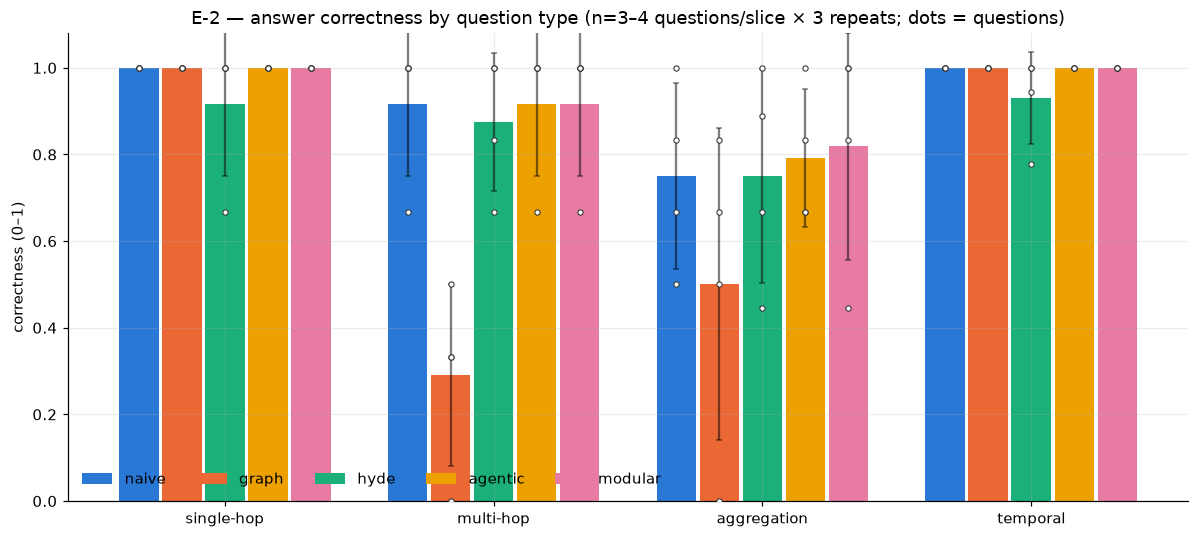

In [3]:
# Fig 1 — E-2: correctness by question type (bars = mean of per-question means,
# whiskers = std across questions, dots = individual questions).
fig, ax = plt.subplots(figsize=(11, 5))
w = 0.8 / len(E2_VARIANTS)
for i, v in enumerate(E2_VARIANTS):
    sub = S2[(S2.variant == v) & (S2.slice.isin(SLICES))].set_index("slice").reindex(SLICES)
    xs = [SLICES.index(s) + i * w for s in SLICES]
    ax.bar(xs, sub.correctness_mean, width=w * 0.92, color=C[v], label=v,
           yerr=sub.correctness_std_across_questions, capsize=2,
           error_kw={"alpha": 0.5})
    q = (R2[R2.variant == v].groupby(["slice", "qid"]).correctness.mean().reset_index())
    ax.scatter([SLICES.index(s) + i * w for s in q.slice], q.correctness,
               s=12, facecolor="white", edgecolor="#333", linewidth=0.7, zorder=3)
ax.set_xticks([i + 0.4 - w / 2 for i in range(len(SLICES))])
ax.set_xticklabels(SLICES)
ax.set_ylabel("correctness (0–1)")
ax.set_ylim(0, 1.08)
ax.legend(ncols=5, loc="lower left", frameon=False)
ax.set_title("E-2 — answer correctness by question type (n=3–4 questions/slice × 3 repeats; dots = questions)")
plt.tight_layout(); plt.show()

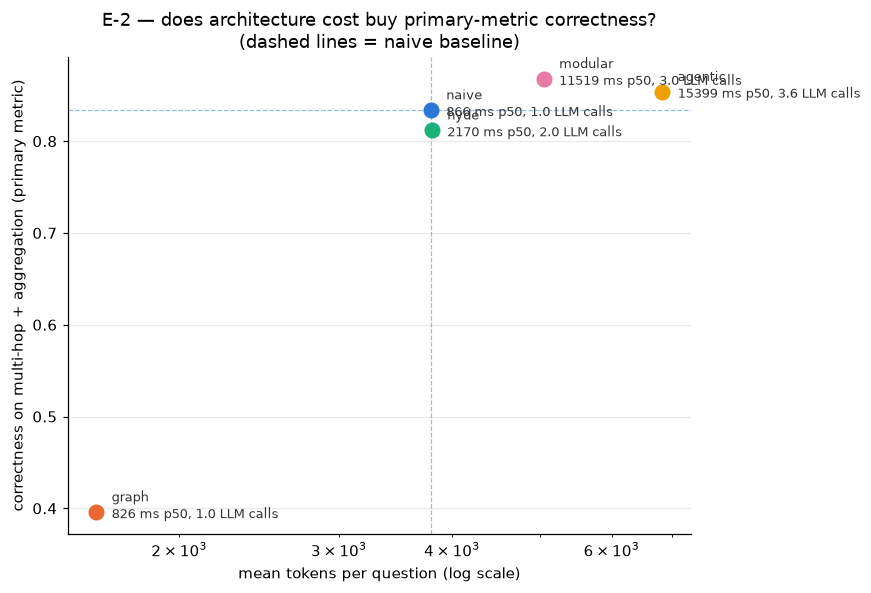

In [4]:
# Fig 2 — E-2 cost-quality frontier: token cost vs the registered primary metric.
fig, ax = plt.subplots(figsize=(8, 5.5))
for v in E2_VARIANTS:
    o = S2[(S2.variant == v) & (S2.slice == "overall")].iloc[0]
    y = prim.loc[v]
    ax.scatter(o.total_tokens, y, s=90, color=C[v], zorder=3)
    ax.annotate(f"{v}\n{o.latency_p50_ms:.0f} ms p50, {o.llm_calls:.1f} LLM calls",
                (o.total_tokens, y), textcoords="offset points", xytext=(10, -4),
                fontsize=8.5, color="#333")
base = S2[(S2.variant == "naive") & (S2.slice == "overall")].iloc[0]
ax.axhline(prim.loc["naive"], color=C["naive"], lw=0.8, ls="--", alpha=0.5)
ax.axvline(base.total_tokens, color=C["naive"], lw=0.8, ls="--", alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("mean tokens per question (log scale)")
ax.set_ylabel("correctness on multi-hop + aggregation (primary metric)")
ax.set_title("E-2 — does architecture cost buy primary-metric correctness?\n(dashed lines = naive baseline)")
plt.tight_layout(); plt.show()

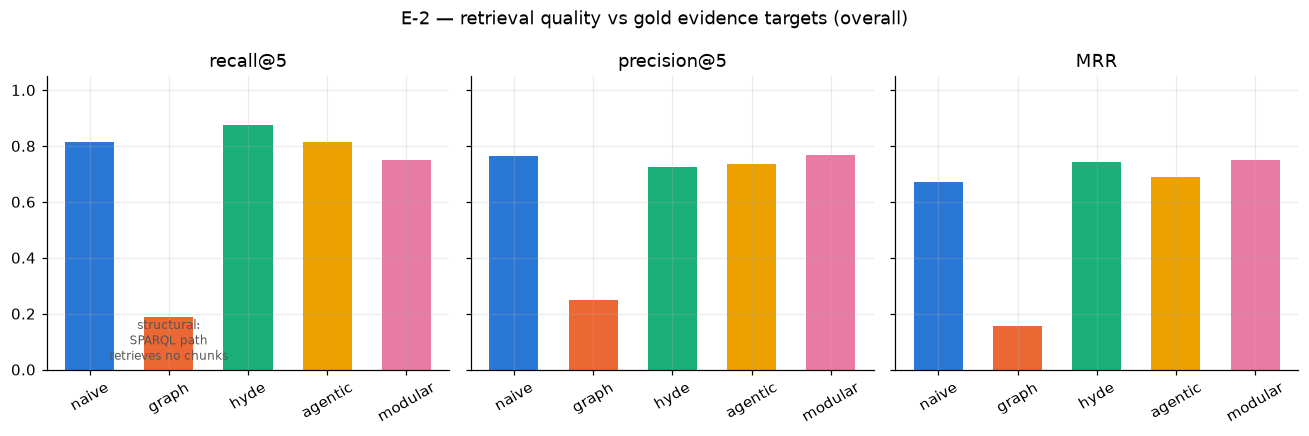

In [5]:
# Fig 3 — E-2 retrieval diagnostics. Graph's ~0 is structural (SPARQL path
# retrieves no text chunks) — annotated, not hidden.
metrics = [("recall_at_k", "recall@5"), ("precision_at_k", "precision@5"), ("mrr", "MRR")]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (col, label) in zip(axes, metrics):
    vals = [S2[(S2.variant == v) & (S2.slice == "overall")][col].iloc[0] for v in E2_VARIANTS]
    ax.bar(E2_VARIANTS, vals, color=[C[v] for v in E2_VARIANTS], width=0.62)
    ax.set_title(label); ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=30)
gi = E2_VARIANTS.index("graph")
axes[0].annotate("structural:\nSPARQL path\nretrieves no chunks",
                 (gi, 0.02), ha="center", va="bottom", fontsize=8, color="#555")
fig.suptitle("E-2 — retrieval quality vs gold evidence targets (overall)")
plt.tight_layout(); plt.show()

,Δ corr overall,Δ corr multi-hop,Δ corr temporal,Δ corr aggregation,Δ faithfulness,Δ cit.support,compl.tokens ×
variant,,,,,,,
prompt_minimal,-0.024,0.000,-0.055,-0.042,0,0.010,0.998
prompt_fewshot,0.007,0.042,0.000,-0.014,0,0.010,0.959
ctx_metadata,0.003,0.042,0.000,-0.028,0,-0.062,0.965
prompt_quote_first,-0.042,-0.111,0.000,-0.055,0,-0.031,1.652


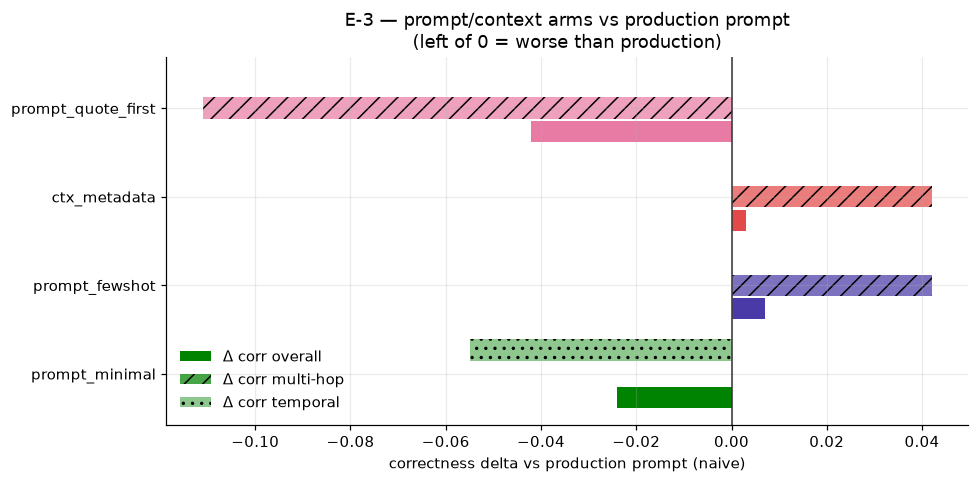

In [6]:
# Table 2 + Fig 4 — E-3: prompt/context engineering deltas vs the production prompt.
base = S3[(S3.variant == "naive")].set_index("slice")
rows = []
for v in E3_VARIANTS[1:]:
    sub = S3[S3.variant == v].set_index("slice")
    rows.append({
        "variant": v,
        "Δ corr overall": sub.loc["overall"].correctness_mean - base.loc["overall"].correctness_mean,
        "Δ corr multi-hop": sub.loc["multi-hop"].correctness_mean - base.loc["multi-hop"].correctness_mean,
        "Δ corr temporal": sub.loc["temporal"].correctness_mean - base.loc["temporal"].correctness_mean,
        "Δ corr aggregation": sub.loc["aggregation"].correctness_mean - base.loc["aggregation"].correctness_mean,
        "Δ faithfulness": sub.loc["overall"].faithfulness - base.loc["overall"].faithfulness,
        "Δ cit.support": sub.loc["overall"].citation_support - base.loc["overall"].citation_support,
        "compl.tokens ×": sub.loc["overall"].completion_tokens / base.loc["overall"].completion_tokens,
    })
t2 = pd.DataFrame(rows).set_index("variant").round(3)
display(t2)

fig, ax = plt.subplots(figsize=(9, 4.5))
dcols = ["Δ corr overall", "Δ corr multi-hop", "Δ corr temporal"]
h = 0.8 / len(dcols)
hatches = [None, "//", ".."]
for j, col in enumerate(dcols):
    ys = np.arange(len(t2)) + j * h
    ax.barh(ys, t2[col], height=h * 0.9,
            color=[C[v] for v in t2.index], alpha=1 - 0.28 * j,
            hatch=hatches[j], label=col)
ax.set_yticks(np.arange(len(t2)) + 0.4 - h / 2)
ax.set_yticklabels(t2.index)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("correctness delta vs production prompt (naive)")
ax.legend(frameon=False, loc="lower left")
ax.set_title("E-3 — prompt/context arms vs production prompt\n(left of 0 = worse than production)")
plt.tight_layout(); plt.show()

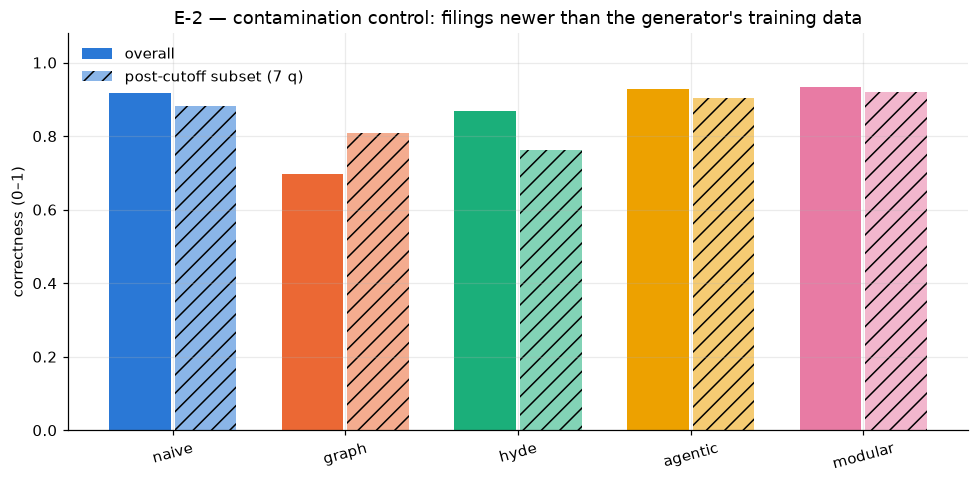

In [7]:
# Fig 5 — contamination control: overall vs post-cutoff correctness (E-2).
# A collapse on post-cutoff questions = parametric knowledge, not retrieval.
fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.38
xs = np.arange(len(E2_VARIANTS))
ov = [S2[(S2.variant == v) & (S2.slice == "overall")].correctness_mean.iloc[0] for v in E2_VARIANTS]
pc = [S2[(S2.variant == v) & (S2.slice == "post_cutoff_subset")].correctness_mean.iloc[0] for v in E2_VARIANTS]
ax.bar(xs - w / 2, ov, width=w * 0.94, color=[C[v] for v in E2_VARIANTS], label="overall")
ax.bar(xs + w / 2, pc, width=w * 0.94, color=[C[v] for v in E2_VARIANTS],
       alpha=0.55, hatch="//", label="post-cutoff subset (7 q)")
ax.set_xticks(xs); ax.set_xticklabels(E2_VARIANTS, rotation=15)
ax.set_ylabel("correctness (0–1)"); ax.set_ylim(0, 1.08)
ax.legend(frameon=False)
ax.set_title("E-2 — contamination control: filings newer than the generator's training data")
plt.tight_layout(); plt.show()

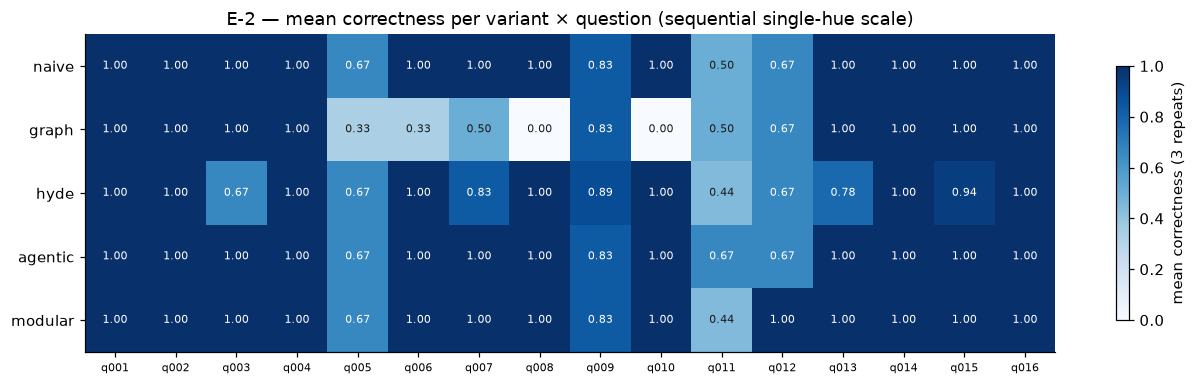

In [8]:
# Fig 6 — per-question drill-down (E-2): where exactly does each architecture fail?
qorder = (pd.read_json(ROOT.parent / "eval" / "questions.v1.jsonl", lines=True)
          .sort_values(["type", "id"]) if (ROOT.parent / "eval" / "questions.v1.jsonl").exists()
          else None)
piv = (R2.groupby(["variant", "qid"]).correctness.mean().unstack()
       .reindex(E2_VARIANTS))
if qorder is not None:
    piv = piv[[q for q in qorder.id if q in piv.columns]]
    col_types = dict(zip(qorder.id, qorder.type))
fig, ax = plt.subplots(figsize=(12, 3.6))
im = ax.imshow(piv.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(len(piv.index)), piv.index)
ax.set_xticks(range(len(piv.columns)),
              [f"{q}\n{col_types.get(q, '')[:6]}" if qorder is not None else q
               for q in piv.columns], fontsize=7.5)
for (i, j), val in np.ndenumerate(piv.values):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
            color="white" if val > 0.6 else "#1a1a19")
fig.colorbar(im, ax=ax, label="mean correctness (3 repeats)", shrink=0.8)
ax.set_title("E-2 — mean correctness per variant × question (sequential single-hue scale)")
ax.grid(False)
plt.tight_layout(); plt.show()

In [9]:
# Pre-registered predictions vs actuals — evaluated AS WRITTEN in .claude/EXPERIMENTS.md.
def g(S, v, sl, col="correctness_mean"):
    r = S[(S.variant == v) & (S.slice == sl)]
    return r[col].iloc[0] if len(r) else np.nan

rows = []
# --- E-2 (primary metric slices) ---
d = g(S2, "agentic", "multi-hop") - g(S2, "naive", "multi-hop")
rows.append(("E-2", "agentic ≥ naive +0.15 on multi-hop (refuted if ≤ 0)",
             f"Δ={d:+.3f}", "SUPPORTED" if d >= 0.15 else ("REFUTED" if d <= 0 else "INCONCLUSIVE")))
tok = g(S2, "agentic", "overall", "total_tokens") / g(S2, "naive", "overall", "total_tokens")
rc = g(S2, "agentic", "overall", "retrieval_calls") / g(S2, "naive", "overall", "retrieval_calls")
rows.append(("E-2", "agentic cost ≥ 2× tokens and ≥ 2× retrieval calls",
             f"{tok:.1f}× tokens, {rc:.1f}× retrievals",
             "SUPPORTED" if tok >= 2 and rc >= 2 else "REFUTED"))
dm = g(S2, "modular", "multi-hop") - g(S2, "naive", "multi-hop")
dr = g(S2, "modular", "overall", "recall_at_k") - g(S2, "naive", "overall", "recall_at_k")
rows.append(("E-2", "modular ≥ naive +0.10 multi-hop AND recall@5 ≥ +0.10 (refuted if both ≤ 0)",
             f"Δcorr={dm:+.3f}, Δrecall={dr:+.3f}",
             "SUPPORTED" if (dm >= 0.10 and dr >= 0.10) else ("REFUTED" if (dm <= 0 and dr <= 0) else "PARTIAL/INCONCLUSIVE")))
dt = g(S2, "graph", "temporal") - g(S2, "naive", "temporal")
ds = g(S2, "graph", "single-hop") - g(S2, "naive", "single-hop")
rows.append(("E-2", "graph ≥ naive +0.15 temporal; single-hop parity ±0.05 (refuted if temporal ≤ 0)",
             f"Δtemporal={dt:+.3f}, Δsingle-hop={ds:+.3f}",
             "SUPPORTED" if (dt >= 0.15 and abs(ds) <= 0.05) else ("REFUTED" if dt <= 0 else "PARTIAL/INCONCLUSIVE")))
hd = max(abs(g(S2, "hyde", sl) - g(S2, "naive", sl)) for sl in SLICES)
rows.append(("E-2", "hyde = naive ±0.05 on all slices",
             f"max |Δ|={hd:.3f}", "SUPPORTED" if hd <= 0.05 else "REFUTED"))
for v in ["graph", "hyde", "agentic", "modular"]:
    fd = g(S2, "naive", "overall", "faithfulness") - g(S2, v, "overall", "faithfulness")
    if fd > 0.3:
        rows.append(("E-2", f"GUARDRAIL: {v} faithfulness drop > 0.3", f"drop={fd:.2f}", "FLAG"))
# --- E-3 ---
dmin = g(S3, "prompt_minimal", "overall") - g(S3, "naive", "overall")
cvd = g(S3, "naive", "overall", "citation_validity") - g(S3, "prompt_minimal", "overall", "citation_validity")
rows.append(("E-3", "minimal: corr within 0.05 AND citation validity drops ≥ 0.2",
             f"Δcorr={dmin:+.3f}, validity drop={cvd:+.3f}",
             "REFUTED (citations held)" if abs(dmin) <= 0.05 and cvd < 0.2 else "CHECK"))
dfs = g(S3, "prompt_fewshot", "overall") - g(S3, "naive", "overall")
rows.append(("E-3", "fewshot: corr ±0.05; citation validity ≥ +0.05",
             f"Δcorr={dfs:+.3f}, validity at ceiling 1.00 both",
             "INCONCLUSIVE (ceiling)" if abs(dfs) <= 0.05 else "CHECK"))
dctx = g(S3, "ctx_metadata", "temporal") - g(S3, "naive", "temporal")
rows.append(("E-3", "ctx_metadata: temporal ≥ +0.05 (refuted if ≤ 0)",
             f"Δtemporal={dctx:+.3f}",
             "SUPPORTED" if dctx >= 0.05 else ("REFUTED" if dctx <= 0 else "INCONCLUSIVE")))
dq = ((g(S3, "prompt_quote_first", "multi-hop") - g(S3, "naive", "multi-hop"))
      + (g(S3, "prompt_quote_first", "temporal") - g(S3, "naive", "temporal"))) / 2
ctx_ratio = g(S3, "prompt_quote_first", "overall", "completion_tokens") / g(S3, "naive", "overall", "completion_tokens")
rows.append(("E-3", "quote_first (suggested): multi-hop+temporal ≥ +0.10 at ≥1.3× compl. tokens (refuted if Δ ≤ 0)",
             f"Δ(mh+temp)/2={dq:+.3f}, {ctx_ratio:.2f}× tokens",
             "SUPPORTED" if dq >= 0.10 else ("REFUTED" if dq <= 0 else "INCONCLUSIVE")))

verdicts = pd.DataFrame(rows, columns=["exp", "pre-registered prediction", "actual", "verdict"])
pd.set_option("display.max_colwidth", 110)
display(verdicts)

,exp,pre-registered prediction,actual,verdict
0,E-2,agentic ≥ naive +0.15 on multi-hop (refuted if ≤ 0),Δ=+0.000,REFUTED
1,E-2,agentic cost ≥ 2× tokens and ≥ 2× retrieval calls,"1.8× tokens, 2.8× retrievals",REFUTED
2,E-2,modular ≥ naive +0.10 multi-hop AND recall@5 ≥ +0.10 (refuted if both ≤ 0),"Δcorr=+0.000, Δrecall=-0.062",REFUTED
3,E-2,graph ≥ naive +0.15 temporal; single-hop parity ±0.05 (refuted if temporal ≤ 0),"Δtemporal=+0.000, Δsingle-hop=+0.000",REFUTED
4,E-2,hyde = naive ±0.05 on all slices,max |Δ|=0.083,REFUTED
5,E-3,minimal: corr within 0.05 AND citation validity drops ≥ 0.2,"Δcorr=-0.024, validity drop=+0.000",REFUTED (citations held)
6,E-3,fewshot: corr ±0.05; citation validity ≥ +0.05,"Δcorr=+0.007, validity at ceiling 1.00 both",INCONCLUSIVE (ceiling)
7,E-3,ctx_metadata: temporal ≥ +0.05 (refuted if ≤ 0),Δtemporal=+0.000,REFUTED
8,E-3,quote_first (suggested): multi-hop+temporal ≥ +0.10 at ≥1.3× compl. tokens (refuted if Δ ≤ 0),"Δ(mh+temp)/2=-0.056, 1.65× tokens",REFUTED


## How to read all of this honestly

- **The baseline is hard to beat here.** E-1 showed the production naive pipeline already at ~0.92 overall correctness with perfect faithfulness and citations on this corpus; its one real weakness is **aggregation coverage** (recall@5 = 0.50 on that slice). Any architecture claiming a win must win *there* — check Fig 1's aggregation group and the primary-metric column of Table 1 before believing any overall number.
- **Cost is half the verdict.** Fig 2 places every architecture against the naive baseline's cost. An architecture matching naive's correctness at 2–4× tokens is a *worse* system for production, whatever its paper says.
- **E-3's headline** is a negative result we predicted against ourselves: the suggested `prompt_quote_first` scaffold **hurt** multi-hop correctness at 1.65× completion tokens (verdict table, last row), and the big production prompt's correctness advantage over a one-line prompt is ~0.02 — prompts are second-order on this pipeline; retrieval coverage is first-order.
- **Limitations**: one corpus (3 mega-cap tech issuers, 6 filings), 16 test questions, one generator model, LLM judge (gemma) with an 11/12 spot-check, free-tier rate limits shaped run pacing (never scoring). Verdicts are registered per-prediction in `.claude/EXPERIMENTS.md`; full narratives in `.claude/evidence/experiments/E-*.md`.

*Generated as part of the pre-registered experiment protocol; every number in this notebook is recomputed from the raw score files on each run.*